## 1. Librerias y conjunto de datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import joblib
import os

In [3]:
df = pd.read_csv(r"/workspaces/steven10015-intro-ml/data/raw/housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.T.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 2. División, escalado y elbow

In [7]:
# 1. Selección de columnas y división (IMPORTANTE)
X = df[["Latitude", "Longitude", "MedInc"]]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [8]:
# 2. Escalado 
scaler = StandardScaler()

# Entrenamos el escalador SOLO con train para no "contaminar"
X_train_scaled = scaler.fit_transform(X_train)
# Aplicamos la misma transformación a test
X_test_scaled = scaler.transform(X_test)

In [9]:
# Código para evitar avisos
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

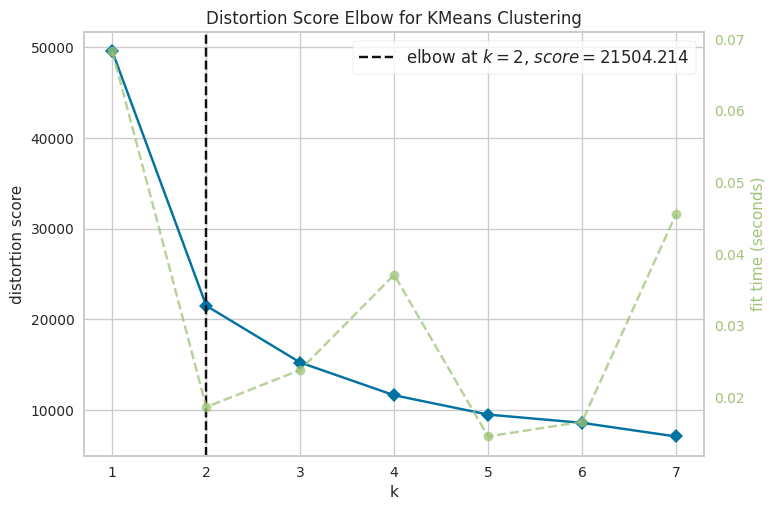

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
# 3. Codo con los datos de entrenamiento escalados
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 8))
visualizer.fit(X_train_scaled) # Aquí se usa la versión escalada
visualizer.show()

El método del codo (Distortion Score) sugiere que el número óptimo de clusters es 2; no obstante, siguiendo los requerimientos del proyecto, se procederá con $k=6$ para obtener una segmentación más detallada de las zonas residenciales

## 3. Entrenamiento

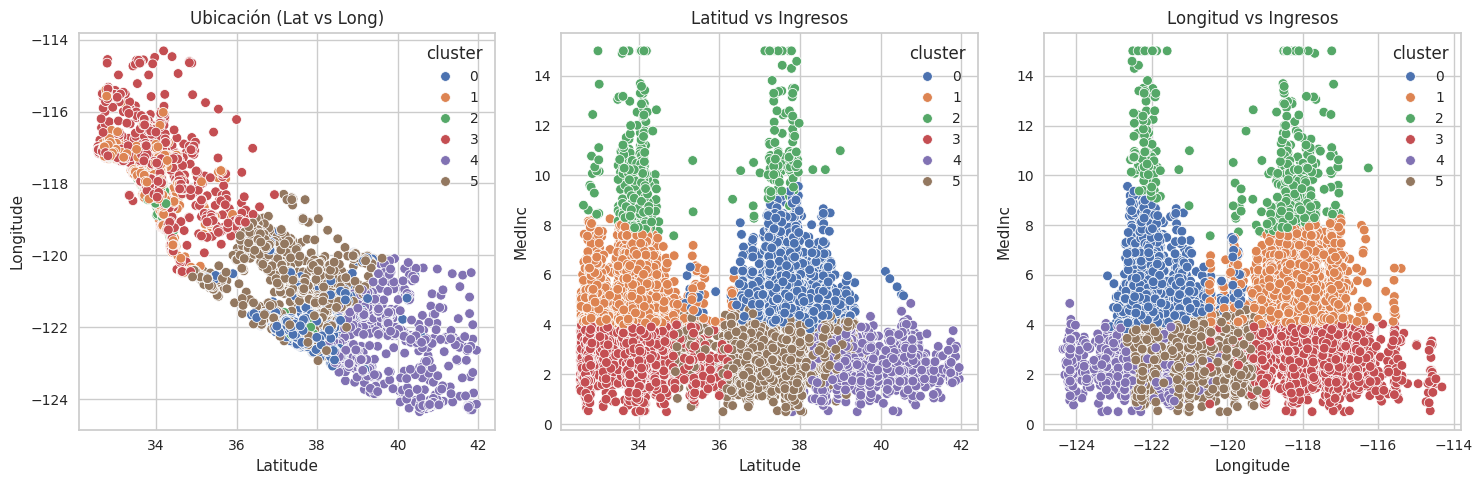

In [11]:
# 1. Entrenar el modelo final con k=6 
kmeans_6 = KMeans(n_clusters=6, random_state=42)
X_train['cluster'] = kmeans_6.fit_predict(X_train_scaled)

# 2. Convertir a categoría para la visualización
X_train['cluster'] = X_train['cluster'].astype('category')

# 3. Visualización en 3 paneles 
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Mapa Geográfico (Latitud vs Longitud)
sns.scatterplot(ax=axis[0], data=X_train, x="Latitude", y="Longitude", hue="cluster", palette="deep")
axis[0].set_title("Ubicación (Lat vs Long)")

# Panel 2: Latitud vs Ingresos (MedInc)
sns.scatterplot(ax=axis[1], data=X_train, x="Latitude", y="MedInc", hue="cluster", palette="deep")
axis[1].set_title("Latitud vs Ingresos")

# Panel 3: Longitud vs Ingresos (MedInc)
sns.scatterplot(ax=axis[2], data=X_train, x="Longitude", y="MedInc", hue="cluster", palette="deep")
axis[2].set_title("Longitud vs Ingresos")

plt.tight_layout()
plt.show()

## 4. Predicción

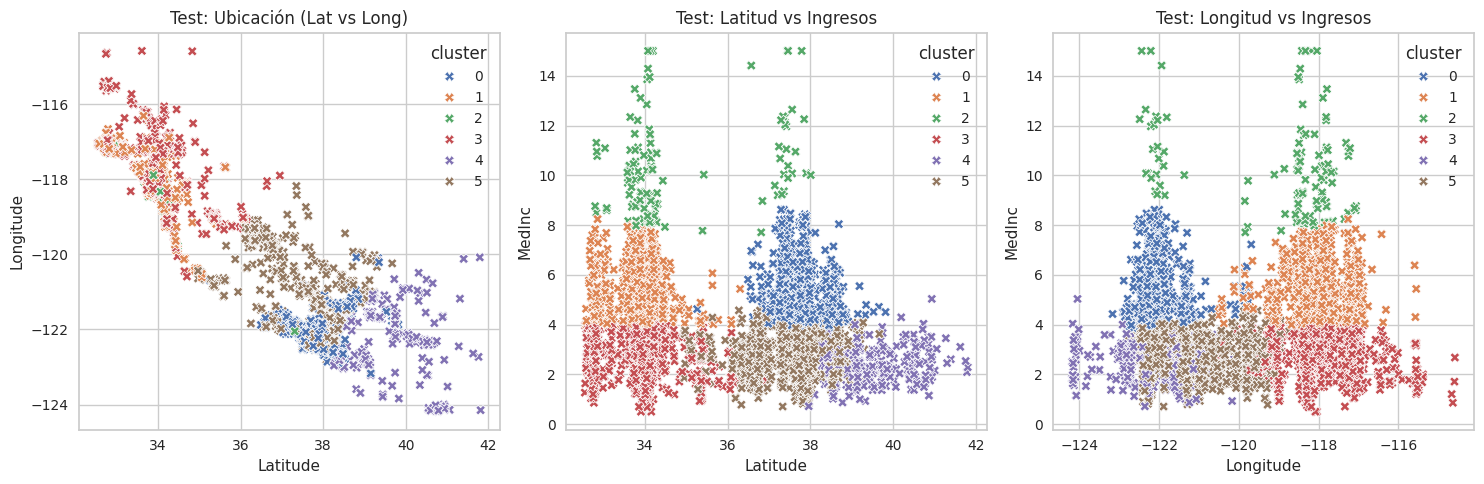

In [12]:
# 1. Predecir los clusters para el conjunto de test escalado
X_test['cluster'] = kmeans_6.predict(X_test_scaled)
X_test['cluster'] = X_test['cluster'].astype('category')

# 2. Visualización en 3 paneles para el conjunto de TEST
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Mapa Geográfico en Test
sns.scatterplot(ax=axis[0], data=X_test, x="Latitude", y="Longitude", hue="cluster", palette="deep", marker='X')
axis[0].set_title("Test: Ubicación (Lat vs Long)")

# Panel 2: Latitud vs Ingresos en Test
sns.scatterplot(ax=axis[1], data=X_test, x="Latitude", y="MedInc", hue="cluster", palette="deep", marker='X')
axis[1].set_title("Test: Latitud vs Ingresos")

# Panel 3: Longitud vs Ingresos en Test
sns.scatterplot(ax=axis[2], data=X_test, x="Longitude", y="MedInc", hue="cluster", palette="deep", marker='X')
axis[2].set_title("Test: Longitud vs Ingresos")

plt.tight_layout()
plt.show()

## 5. Entrenamiento de modelo supervisado

In [13]:
# 1. Definir el modelo supervisado
# Usamos Random Forest porque es excelente para entender fronteras complejas
clf = RandomForestClassifier(random_state=42)

# 2. Entrenar el modelo
# Usamos los datos de entrenamiento ESCALADOS y las etiquetas generadas por K-Means
clf.fit(X_train_scaled, X_train['cluster'])

# 3. Realizar las predicciones sobre el conjunto de TEST escalado
y_pred = clf.predict(X_test_scaled)

# 4. Generar y mostrar el reporte de métricas
print("--- Reporte de Clasificación Supervisada ---")
print(classification_report(X_test['cluster'], y_pred))

--- Reporte de Clasificación Supervisada ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       557
           1       1.00      1.00      1.00       897
           2       1.00      0.97      0.99       116
           3       1.00      1.00      1.00      1397
           4       0.98      0.99      0.99       246
           5       0.99      0.99      0.99       915

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



## 6. Guardar modelos

In [14]:
# Definimos la ruta absoluta 
folder_path = '/workspaces/steven10015-intro-ml/models'

# 1. Guardar el modelo K-Means 
joblib.dump(kmeans_6, os.path.join(folder_path, 'kmeans_model.pkl'))

# 2. Guardar el modelo Random Forest 
joblib.dump(clf, os.path.join(folder_path, 'random_forest_classifier.pkl'))

print(f"Modelos guardados exitosamente en: {os.path.abspath(folder_path)}")

Modelos guardados exitosamente en: /workspaces/steven10015-intro-ml/models
